In [48]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [49]:
df = pd.read_csv("./Data/data.csv", parse_dates=['Month'])
df.sort_values('Month', inplace=True)
df.set_index('Month', inplace=True)
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


# Data priview

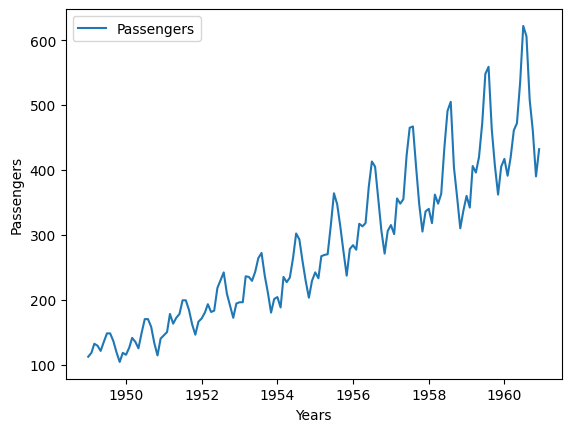

In [50]:
plt.plot(df, label='Passengers')
plt.legend()
plt.xlabel("Years")
plt.ylabel("Passengers")
plt.show()

# Augmented Dickey-Fuller Test

In [51]:
res = adfuller(df)
print(f"ADF Statistics: {res[0]}")
p_val = res[1]
print(f"P-Value: {p_val}")
print("-" * 30, end='\n')
if p_val > 0.05:
    print("Fail to reject Null Hypothesis")
else:
    print("Reject null hypothesis")

ADF Statistics: 0.8153688792060482
P-Value: 0.991880243437641
------------------------------
Fail to reject Null Hypothesis


# ACF, PACF Plots

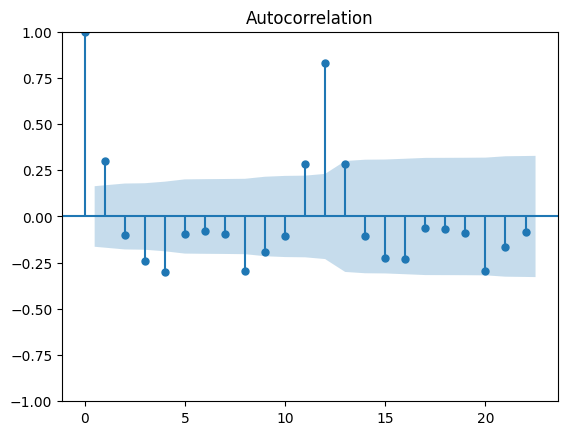

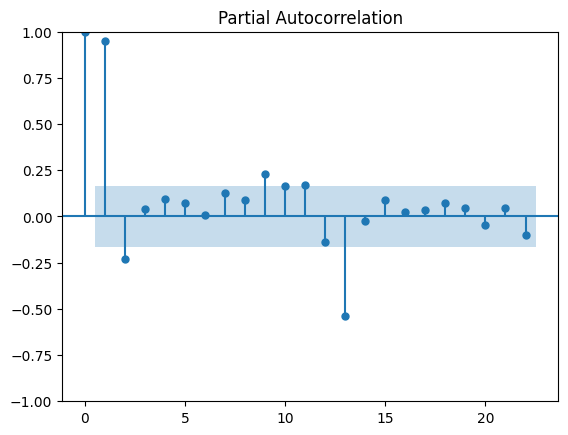

In [52]:
plot_acf(df.diff().dropna())
plot_pacf(df)
plt.show()

# Train Test split

In [53]:
size = int(len(df) * 0.8)

train = df[:size]
test = df[size:]

print(train.shape, test.shape, end=' ')

(115, 1) (29, 1) 

# Arima Model (1, 2, 1)

In [54]:
model = ARIMA(
    train,
    order=(1, 2, 1)
)
result = model.fit()

# Predict Values

In [55]:
forecast_values = result.forecast(len(test))

# Predicted Values Plot

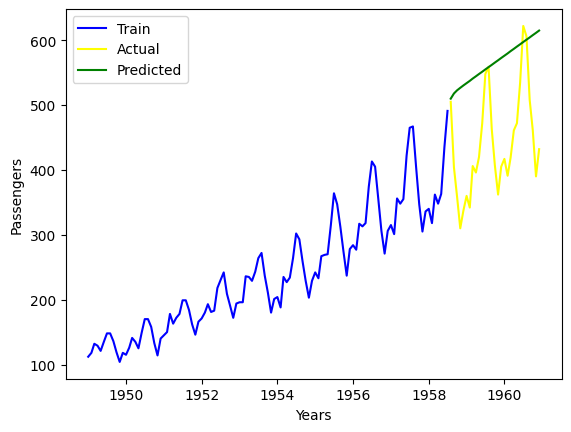

In [56]:
plt.plot(train, color='blue', label='Train')
plt.plot(test, color='yellow', label='Actual')
plt.plot(forecast_values, color='green', label='Predicted')
plt.legend()
plt.xlabel("Years")
plt.ylabel("Passengers")
plt.show()

# Results

In [58]:
mae = mean_absolute_error(test, forecast_values)
rmse = mean_squared_error(test, forecast_values) ** 0.5
mape = mean_absolute_percentage_error(test, forecast_values)


print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Value: {rmse}")
print(f"Mean Absolute Percentage Error: {mape}")

Mean Absolute Error: 126.99264541033335
Root Mean Squared Value: 143.3556289932261
Mean Absolute Percentage Error: 0.320351328903959
